# melt_phase_comp.ipynb

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import importlib
import sys
import rioxarray as rxr
from pathlib import Path
import xarray as xr
import contextily as ctx
import pandas as pd
from affine import Affine
from shapely.geometry import shape
from rasterio.features import shapes
import copy


# gets rid of a lot of annoying warnings, we know there are NaNs (might want to remove this to double check)
import warnings
warnings.filterwarnings("ignore")


In [2]:
sys.path.insert(1, '../scripts/')

In [3]:
import metadata as metadata
import plotting as plotting
import melt_phases as melt_phases


In [4]:
import importlib
importlib.reload(metadata)
importlib.reload(plotting)
importlib.reload(melt_phases)


<module 'melt_phases' from '/glade/u/home/rossamower/school/uw/cues_git/cues_sentinel_snowmodel/python/figures/../scripts/melt_phases.py'>

# Functions

In [5]:
def tif_to_shape(mask_da):
    """
    Converts a boolean xarray to a geopandas shape.
    """
  # Boolean mask (or 0/1 mask)
    mask = mask_da.values.astype(np.uint8)

    # Build affine transform from xarray coordinates
    x = mask_da.x.values
    y = mask_da.y.values

    dx = np.abs(x[1] - x[0])
    dy = np.abs(y[1] - y[0])

    transform = Affine(
        dx, 0, x.min() - dx/2,
        0, -dy, y.max() + dy/2
    )

    # Polygonize
    geoms = [
        shape(geom)
        for geom, value in shapes(mask, mask=mask.astype(bool), transform=transform)
        if value == 1
    ]

    gdf = gpd.GeoDataFrame(
        geometry=geoms,
        crs=mask_da.rio.crs
    )

    # Merge all polygons into one watershed polygon
    gdf = gdf.dissolve()  

    return gdf

# Inputs

In [6]:
YEAR1 = 2017
iy = 32
ix = 40

# Load data

## Geography

In [7]:
importlib.reload(metadata)
# tuolumne
tuolumne_cfg = metadata.load_yaml(Path(f"../../configs/Tuolumne.yaml"))
# ASO
aso_cfg = metadata.load_yaml(Path(f"../../configs/ASO.yaml"))
_,aso_crs = metadata.get_shapefile_fpath(aso_cfg,"basin_shapefile","USCASJ")


In [8]:
# stream gauge location.
lyell_blw_maclure_gauge_lon_lat = [-119.26180,37.77821]
# basin boundary.
lyell_water_shed = rxr.open_rasterio('../../data/shapefiles/Lyell_Watershed.tif').squeeze(drop = True)
lyell_gdf_proj = tif_to_shape(lyell_water_shed)

## SnowModel

In [9]:
# melt phases.
ds_sm_yr1_lyell_matched = xr.load_dataset('../../data/tuolumne/snowmodel/conceptual_phases.nc')
# variable output.
sm_point_ds_2017 = xr.load_dataset('../../data/tuolumne/snowmodel/conceptual_output.nc')

## Sentinel

In [10]:
# backscatter.
s1_bsc_yr1_ds = xr.load_dataset(f'/glade/campaign/ral/hap/rmower/pixel/sentinel/tuolumne/100_m/{YEAR1}/bscatter/s1_backscatter_{YEAR1-1}_10_01_{YEAR1}_10_01_100m.nc').rename({'__xarray_dataarray_variable__':'bscatter'}).rio.clip(lyell_gdf_proj.geometry)
s1_bsc_prev_yr1_ds = xr.load_dataset(f'/glade/campaign/ral/hap/rmower/pixel/sentinel/tuolumne/100_m/{YEAR1-1}/bscatter/s1_backscatter_{YEAR1-2}_10_01_{YEAR1-1}_10_01_100m.nc').rename({'__xarray_dataarray_variable__':'bscatter'}).rio.clip(lyell_gdf_proj.geometry)
# reference.
s1_ref_yr1_ds = xr.load_dataset(f'/glade/campaign/ral/hap/rmower/pixel/sentinel/tuolumne/100_m/{YEAR1}/melt_thresh/reference/reference_images_{YEAR1-1}-07-15_{YEAR1-1}-09-01.nc').rio.write_crs(aso_crs).rio.clip(lyell_gdf_proj.geometry)
# melt phases.
ds_s1_vv_yr1 = xr.load_dataset(f"{tuolumne_cfg['sentinel_fpath']['melt_phases']}vv/{YEAR1}_wetness_phase.nc")
ds_s1_vv_yr1 = ds_s1_vv_yr1.rio.write_crs(aso_crs).rio.clip(lyell_gdf_proj.geometry)


## Air Temperature

In [11]:
wrf_temp_daily = xr.load_dataset('../../data/tuolumne/air_temp/conceptual_fig_airT.nc')

# Conceptual Figure

In [12]:
def backscatter_anomalies(
    ds_s1,
    s1_bsc_ds,
    s1_ref_ds,
    idx_=None,
    idy_=None,
    qcPass=True,
    geog: gpd.GeoDataFrame = None,
    xmin_: str = None,
    xmax_: str = None,
    showRef_Period: bool = False,
    dropOrbit64: bool = False,
    ax = None,
    title=None,
    pltLegend: bool = True,
    add_buff: float = 0.0,
):
    sim_year = int(np.unique(ds_s1.time.dt.year.values))
    TAU_DB = -2.0  # VV drop threshold (dB)

    # -- Pixel selection -------------------------------------------------------
    qc_ok = ds_s1['qc_ok'].values

    if idx_ is None or idy_ is None:
        y_min, y_max = float(s1_bsc_ds.y.min()), float(s1_bsc_ds.y.max())
        x_min, x_max = float(s1_bsc_ds.x.min()), float(s1_bsc_ds.x.max())
        yy, xx = np.meshgrid(ds_s1.y.values, ds_s1.x.values, indexing='ij')
        spatial_mask  = (yy >= y_min) & (yy <= y_max) & (xx >= x_min) & (xx <= x_max)
        combined_mask = (qc_ok == qcPass) & spatial_mask
        valid_yx = np.argwhere(combined_mask)
        if len(valid_yx) == 0:
            raise ValueError(f"No pixels with qc_ok == {qcPass} within s1_bsc_ds extent")
        chosen     = valid_yx[np.random.randint(len(valid_yx))]
        idy_, idx_ = int(chosen[0]), int(chosen[1])

    y_val    = float(ds_s1.y.values[idy_])
    x_val    = float(ds_s1.x.values[idx_])
    pixel_qc = bool(qc_ok[idy_, idx_])
    print(f"Pixel  idy={idy_}, idx={idx_}  |  y={y_val:.1f}, x={x_val:.1f}  |  qc_ok={pixel_qc}")

    # -- Extract per-time VV backscatter at this pixel (linear -> dB) ----------
    times        = s1_bsc_ds['time'].values
    orbits       = s1_bsc_ds['sat:relative_orbit'].values   # shape (time,)
    orbit_states = s1_bsc_ds['sat:orbit_state'].values      # shape (time,)

    bsc_vv_linear = (
        s1_bsc_ds['bscatter']
        .sel(y=y_val, x=x_val, method='nearest')
        .sel(band='vv')
        .values   # shape (time,), linear units
    )
    bsc_vv_db = 10.0 * np.log10(bsc_vv_linear)  # convert to dB

    # -- Compute DVV per orbit: ref also linear -> dB, then subtract -----------
    delta_vv = np.full(len(times), np.nan)
    for orbit in np.unique(orbits):
        t_mask = orbits == orbit
        ref_linear = float(
            s1_ref_ds['reference_bscatter']
            .sel(**{'sat:relative_orbit': int(orbit)}, band='vv')
            .sel(y=y_val, x=x_val, method='nearest')
            .values
        )
        ref_db = 10.0 * np.log10(ref_linear)
        delta_vv[t_mask] = (bsc_vv_db[t_mask]+ add_buff) - ref_db
        print(f"  orbit {int(orbit):3d}  ref_linear={ref_linear:.4f}  ref_db={ref_db:.2f} dB  "
              f"DVV range [{np.nanmin(delta_vv[t_mask]):.2f}, {np.nanmax(delta_vv[t_mask]):.2f}] dB")

    # -- Split by orbit and pass/fail threshold --------------------------------
    am_mask  = orbit_states == 'descending'          # orbit 144
    pm64_mask  = (orbit_states == 'ascending') & (orbits == 64)
    pm137_mask = (orbit_states == 'ascending') & (orbits == 137)

    # -- Print reason for failure ----------------------------------------------
    if dropOrbit64:
        s1_bsc_ds["bscatter"] = s1_bsc_ds.bscatter.where(
            s1_bsc_ds["sat:relative_orbit"] != 64
        )
    
    print(idy_,idx_)
    result = melt_phases.run_s1_vv_year(s1_bsc_ds, s1_ref_ds, idy=idy_, idx=idx_, year=sim_year, cfg=melt_phases.MarinS1VVCfg())
    print(result['qc_ok'], result['qc_reason'])
    print(result['diagnostics']['per_orbit'])

    # -- Extract per-orbit minima from diagnostics --------------------------------
    orbit_minima = {}

    for orbit_key, diag in result["diagnostics"]["per_orbit"].items():
        t_min = diag.get("t_min", None)

        if t_min is None:
            continue

        orbit = int(orbit_key)
        t_min = pd.Timestamp(t_min)

        min_mask = (
            (orbits == orbit) &
            (pd.to_datetime(times) == t_min)
        )

        if np.any(min_mask):
            orbit_minima[orbit] = min_mask


    
    # -- Plot ------------------------------------------------------------------
    if ax is None:
        fig, [ax0,ax1] = plt.subplots(1, 2, figsize=(13, 6), dpi=200)

        # Spatial panel
        ds_s1.where(ds_s1.qc_ok == qcPass).qc_ok.plot(ax=ax0, alpha=0.5, add_colorbar=False)
        ax0.scatter(ds_s1.x[idx_], ds_s1.y[idy_], label='sel pix', color = 'red',zorder=5)
        ax0.legend()
        ax0.set_title('')
        ax0.axis('off')
        if geog is not None: geog.plot(ax=ax0, color='none', edgecolor='red')
        ctx.add_basemap(ax=ax0, crs=aso_crs, source=ctx.providers.Esri.WorldImagery, attribution=False)
    else:
        ax1 = ax
    # -- Highlight per-orbit minima ------------------------------------------------
    for orbit, min_mask in orbit_minima.items():

        if dropOrbit64 and orbit == 64:
            continue

        if orbit == 144:
            color = "k"
            label = "Orbit minimum"
        elif orbit in [64, 137]:
            color = "k"
            label = "Orbit minimum"
        else:
            color = "black"
            label = "Orbit minimum"

        min_ = ax1.scatter(
            times[min_mask],
            delta_vv[min_mask],
            s=110,
            facecolors="none",
            edgecolors=color,
            linewidths=2.0,
            zorder=6,
            label=label if orbit == 144 else None,
        )
    

    # Time series panel — AM and each PM orbit separately
    if am_mask.any():
        l1 = ax1.plot(times[am_mask], delta_vv[am_mask], linewidth=1.2, alpha=0.7, zorder=2, linestyle ='-',color = 'C5',marker = 'o',markersize = 5, label = r'$\Delta\sigma_{AM}$ (orbit 144)')
    if pm137_mask.any():
        l2 = ax1.plot(times[pm137_mask], delta_vv[pm137_mask], color='C8', linewidth=1.2, linestyle = '-',marker = 'o',markersize = 5, alpha=0.7, zorder=2, label = r'$\Delta\sigma_{PM}$ (orbit 137)')

    if dropOrbit64:
        pass
    else:
        if pm64_mask.any():
            l3 = ax1.plot(times[pm64_mask], delta_vv[pm64_mask], color='C8', linewidth=1.2,linestyle = '--', marker = 'o', markersize = 5,alpha=0.7, zorder=2,label=r'$\Delta\sigma_{PM}$ (orbit 64)')

    if pltLegend:
        ax1.axhline(TAU_DB, color='black', linestyle='--', linewidth=1.2,
                  label=f'Drop Threshold ({TAU_DB} dB)')
    else:
        dt = ax1.axhline(TAU_DB, color='black', linestyle='--', linewidth=1.2,label=f'Drop Threshold ({TAU_DB} dB)')
    ax1.legend(handles = [min_,dt],labels = ['Orbit minimum',f'Drop Threshold ({TAU_DB} dB)'],loc = 'lower left')
    ax1.axhline(0, color='gray', linestyle='-', linewidth=0.7, alpha=0.5)
    if showRef_Period:
        start = pd.Timestamp(f"{sim_year-1}-07-15")
        end   = pd.Timestamp(f"{sim_year-1}-09-01")
        ax1.axvline(start, color='k', linestyle='--')
        ax1.axvline(end, color='k', linestyle='--')

        # Shade between them
        ax1.axvspan(start, end, color='lightgray', label = 'Reference image\naggregate period',alpha=0.7,zorder = 99)

    qc_label = 'QC Pass' if pixel_qc else 'QC Fail'
    if title is None: 
        ax1.set_title(f'DVV Backscatter Anomaly  |  idy={idy_}, idx={idx_}  [{qc_label}]', fontweight='bold')
    else:
        ax1.set_title(title)
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Backscatter Anomaly\n' + r'$\Delta\sigma$ [dB]')
    if pltLegend:
        ax1.legend(
            fontsize=8,
            loc="center right",
            bbox_to_anchor=(-0.02, 0.5),  # move legend left of the axes
            borderaxespad=0.0,
            frameon=True
        )
    if (xmin_ is not None) and (xmax_ is not None):
        ax1.set_xlim(np.datetime64(xmin_),np.datetime64(xmax_))
    # ax1.grid(axis, alpha=0.3)
    ax1.grid(axis = 'x', linestyle='--')

    # plt.tight_layout()
    return ax,result


In [13]:
import matplotlib.dates as mdates
def subplot0(ds_144,
             ds_137,
             ds_64,
             ax,
             temp_da = None,
            sim_years = [2017,2018],
            xmax_ = '2018-10-01',
            xmin_ = '2016-07-01'):

    count = 0
    for sim_year in sim_years:
        start = pd.Timestamp(f"{sim_year-1}-07-15")
        end   = pd.Timestamp(f"{sim_year-1}-09-01")
        ax.axvline(start, color='k', linestyle='--')
        ax.axvline(end, color='k', linestyle='--')

        # Shade between them
        if count == 0:
            l0= ax.axvspan(start, end, color='lightgray', label = 'Reference image\naggregate period',alpha=0.3,zorder = 99)
        else:
            ax.axvspan(start, end, color='lightgray',alpha=0.3,zorder = 99)
        
        count += 1
    count = 0
    for sim_year in sim_years:
        start = pd.Timestamp(f"{sim_year}-01-01")
        end   = pd.Timestamp(f"{sim_year}-07-01")
        ax.axvline(start, color='k', linestyle='--')
        ax.axvline(end, color='k', linestyle='--')

        # Shade between them
        if count == 0:
            l1= ax.axvspan(start, end, color='lightblue', label = 'Wetness evaluation\nperiod',alpha=0.3,zorder = 99)
        else:
            ax.axvspan(start, end, color='lightblue',alpha=0.3,zorder = 99)
        count += 1
    l4 = ax.plot(ds_144.time,(10*np.log10(ds_144.bscatter[:,0])),zorder = 1,color = 'C5',linestyle = '-',alpha = 0.7)
    l5 = ax.plot(ds_137.time,(10*np.log10(ds_137.bscatter[:,0])),zorder = 2,color = 'C8',linestyle = '-',alpha = 0.7)
    ax.plot(ds_64.time,(10*np.log10(ds_64.bscatter[:,0])),zorder = 3,color = 'C8',linestyle = '--',alpha = 0.7)
    ax.set_xlim(np.datetime64(xmin_),np.datetime64(xmax_))
    ax.set_ylabel('Backscatter\n'+ r'$\sigma$ [dB]')
    # Only show month abbreviations
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    if temp_da is not None:
        temp_max = temp_da.resample({'Time':'1D'}).max()
        temp_min = temp_da.resample({'Time':'1D'}).min()

        ax_ = ax.twinx()
        l2= temp_max.plot(ax=ax_,color = 'mediumpurple',linewidth = 0.75,alpha = 0.7)
        l3= temp_min.plot(ax=ax_,color = 'darkviolet',linewidth = 0.75,alpha = 0.7)
        ax_.axhline(0,linestyle = '--',linewidth = 0.5,color = 'purple')
        ax_.set_ylim(-20,20)
        ax_.set_xlim(np.datetime64(xmin_),np.datetime64(xmax_))
        ax_.set_ylabel('Temperature',color = 'purple')
        ax_.set_title('')
        return ax, [l0,l1,l2[0],l3[0]],['Reference image\naggregate period','Wetness evaluation\nperiod','Tmax','Tmin']
    else:
        return ax, [l0,l1,l4[0],l5[0]],['Reference image\naggregate period','Wetness evaluation\nperiod','AM orbit','PM orbit']
    

In [14]:
def plot_phase_intervals(ax, phase_ds, label="Phase"):
    phase_colors = {
        "dry": "white",
        "moist": "#AEC7E8",
        "ripe": "#FFBB78",
        "output": "#FF7F0E",
    }

    display_labels = {
        "dry": "Dry",
        "moist": "Moistening",
        "ripe": "Ripening",
        "output": "Draining",
    }

    invalid_color = "lightgray"

    starts = phase_ds.interval_start.values
    ends = phase_ds.interval_end.values
    phases = phase_ds.phase_name.values

    for t0, t1, phase in zip(starts, ends, phases):
        ax.axvspan(
            t0,
            t1,
            ymin=0,
            ymax=1,
            facecolor=phase_colors.get(str(phase), invalid_color),
            edgecolor="none",
        )

    ax.set_ylim(0, 1)
    ax.set_yticks([])
    # ax.set_ylabel(label, rotation=0, ha="right", va="center")

    ax.spines[["left", "right", "top"]].set_visible(True)
    ax.tick_params(axis="y", length=0)
    ax.grid(axis = 'x', linestyle='--')

    return ax

In [15]:
import numpy as np
import pandas as pd
import matplotlib.dates as mdates

def plot_sm_phases(ax, sm_phase_ds, label="SM"):
    """
    Plot SnowModel phase progression.

    phase_code:
        0 = dry
        1 = moist
        2 = ripe
        3 = draining
    """

    phase_colors = {
        0: "white",
        1: "#AEC7E8",   # Moistening
        2: "#FFBB78",   # Ripening
        3: "#FF7F0E",   # Draining
    }

    phase = sm_phase_ds.phase_code.values.astype(int)
    time = pd.to_datetime(sm_phase_ds.time.values)

    # Find indices where the phase changes
    change_idx = np.concatenate((
        [0],
        np.where(np.diff(phase) != 0)[0] + 1,
        [len(phase)]
    ))

    # Plot each constant-phase interval
    for i in range(len(change_idx) - 1):
        start = change_idx[i]
        end = change_idx[i + 1]

        t0 = time[start]

        # Use next timestep as the interval end, except for the final interval
        if end < len(time):
            t1 = time[end]
        else:
            # extend final interval by one timestep
            dt = time[-1] - time[-2]
            t1 = time[-1] + dt

        ax.axvspan(
            t0,
            t1,
            facecolor=phase_colors.get(phase[start], "lightgray"),
            edgecolor="none",
        )

    ax.set_ylim(0, 1)
    ax.set_yticks([])

    ax.spines["left"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.spines["top"].set_visible(True)
    ax.tick_params(axis="y", length=0)
    ax.grid(axis = 'x', linestyle = '--')
    # Only show month abbreviations
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

    return ax

In [16]:
def plot_ml_sm(
    sm_point_ds: xr.Dataset,
    ax0,
    vmin_: float = -15.0,
    vmax_: float = 0.0,
    cmap_: str = 'inferno',
    start_date: np.ndarray = np.datetime64('2017-01-01'),
    end_date: np.ndarray = np.datetime64('2017-07-01'),
              ):
    swed_top = sm_point_ds_2017.ml_swed.dropna(dim = 'layer',how = 'all')
    temp_ml_ds = sm_point_ds_2017['tsfc'].dropna(dim = 'layer',how = 'all')
    swed_ml_ds = swed_top[:,:].sum(dim = 'layer') - swed_top[:,::-1].cumsum(dim = 'layer',skipna = True)
    # 4️⃣ Main time series
    l1, = swed_top[:,:].sum(dim='layer').plot(ax=ax0, label='SWE', color='black')

    xlim = ax0.get_xlim()
    ylim = ax0.get_ylim()

    # 5️⃣ Top layer gradient fill
    gradient = plotting.fill(
        swed_ml_ds.where(swed_ml_ds >= 0)[:,0].time.values,
        swed_ml_ds.where(swed_ml_ds >= 0)[:,0].values,
        swed_top[:,:].sum(dim='layer').values,
        temp_ml_ds[:,-1].values,
        vmin_,
        vmax_,
        axes=ax0,
        cmap_=cmap_
    )

    # Remaining layers
    for i in range(1, swed_ml_ds.shape[1]):
        gradient = plotting.fill(
            swed_ml_ds.where(swed_ml_ds >= 0)[:,i].time.values,
            swed_ml_ds.where(swed_ml_ds >= 0)[:,i-1].values,
            swed_ml_ds.where(swed_ml_ds >= 0)[:,i].values,
            temp_ml_ds[:,-i-1].values,
            vmin_,
            vmax_,
            axes=ax0,
            cmap_=cmap_
    )
    l2, = sm_point_ds.where(sm_point_ds.time >= start_date,drop = True).where(sm_point_ds.time <= end_date,drop = True).roff[:].cumsum().plot(ax=ax0,color = 'C2',label = 'ROFF')

    # Axes formatting
    ax0.set_xlim(xlim)
    ax0.set_ylim(ylim)
    ax0.set_ylim(0,2)
    ax0.grid(axis = 'x', linestyle='--')
    ax0.set_xlim(start_date,end_date)
    ax0.set_title("",fontweight = 'bold')
    ax0.set_ylabel("SWE\n[m]")
    ax0.tick_params(axis='x', labelbottom=False)
    ax0.set_xlabel("")
    ax0_ = ax0.twinx()
    l3, = sm_point_ds.where(sm_point_ds.time >= start_date,drop = True).where(sm_point_ds.time <= end_date,drop = True).where(sm_point_ds.sum(dim = 'layer').melt[:] > 0).sum(dim='layer').melt[:].plot(ax=ax0_,label = 'LWE')
    ax0_.set_ylabel('Total Liquid Water in Column\n[m]',fontweight = 'bold',color = 'C0')
    ax0_.set_title('')
    ax0_.set_ylim(0,0.02)

    ax0.legend(handles = [l1,l2,l3], labels = ['SWE','ROFF','LWE'],loc = 'upper right')

    return [l1,l2,l3],['SWE','ROFF','LWE']

In [17]:
from matplotlib.patches import ConnectionPatch
def connect_axes_by_date(fig, ax_top, ax_bottom, date, 
                         y_top_frac=0.0, y_bottom_frac=1.0,
                         color="0.25", lw=1.2, ls="--", alpha=0.8):
    """
    Draw a connector from ax_top to ax_bottom at the same date.
    y_*_frac are in axes-fraction coordinates: 0=bottom, 1=top.
    """
    date = np.datetime64(date)

    con = ConnectionPatch(
        xyA=(date, y_top_frac),
        coordsA=ax_top.get_xaxis_transform(),     # x=data, y=axes fraction
        xyB=(date, y_bottom_frac),
        coordsB=ax_bottom.get_xaxis_transform(),  # x=data, y=axes fraction
        color=color,
        lw=lw,
        ls=ls,
        alpha=alpha,
        clip_on=False,
        zorder=20,
    )

    fig.add_artist(con)
    return con

Pixel  idy=32, idx=40  |  y=4181250.0, x=301650.0  |  qc_ok=True
  orbit  64  ref_linear=0.1249  ref_db=-9.04 dB  DVV range [-7.71, 5.14] dB
  orbit 137  ref_linear=0.1022  ref_db=-9.91 dB  DVV range [-8.36, 4.40] dB
  orbit 144  ref_linear=0.1516  ref_db=-8.19 dB  DVV range [-10.83, 1.78] dB
32 40
True OK
{'64': {'ok': True, 'reason': 'OK', 'ref': -9.035604476928711, 't_min': Timestamp('2017-06-02 01:50:22.994654'), 'a_min': -8.711267471313477, 'f_below': 0.3333333333333333, 'noisy_diag': {'jackknife_spread_days': 12.0, 'local_n': 5, 'distinct_q10_minus_min_db': 0.29268341064453196, 'local_low_count': 1, 'stability_fail': False, 'distinct_fail': True, 'persist_fail': True, 'noisy': False}}, '137': {'ok': True, 'reason': 'OK', 'ref': -9.907580375671387, 't_min': Timestamp('2017-05-26 01:58:36.665185'), 'a_min': -9.362713813781738, 'f_below': 0.23529411764705882, 'noisy_diag': {'jackknife_spread_days': 12.0, 'local_n': 4, 'distinct_q10_minus_min_db': 0.22985000610351491, 'local_low_coun

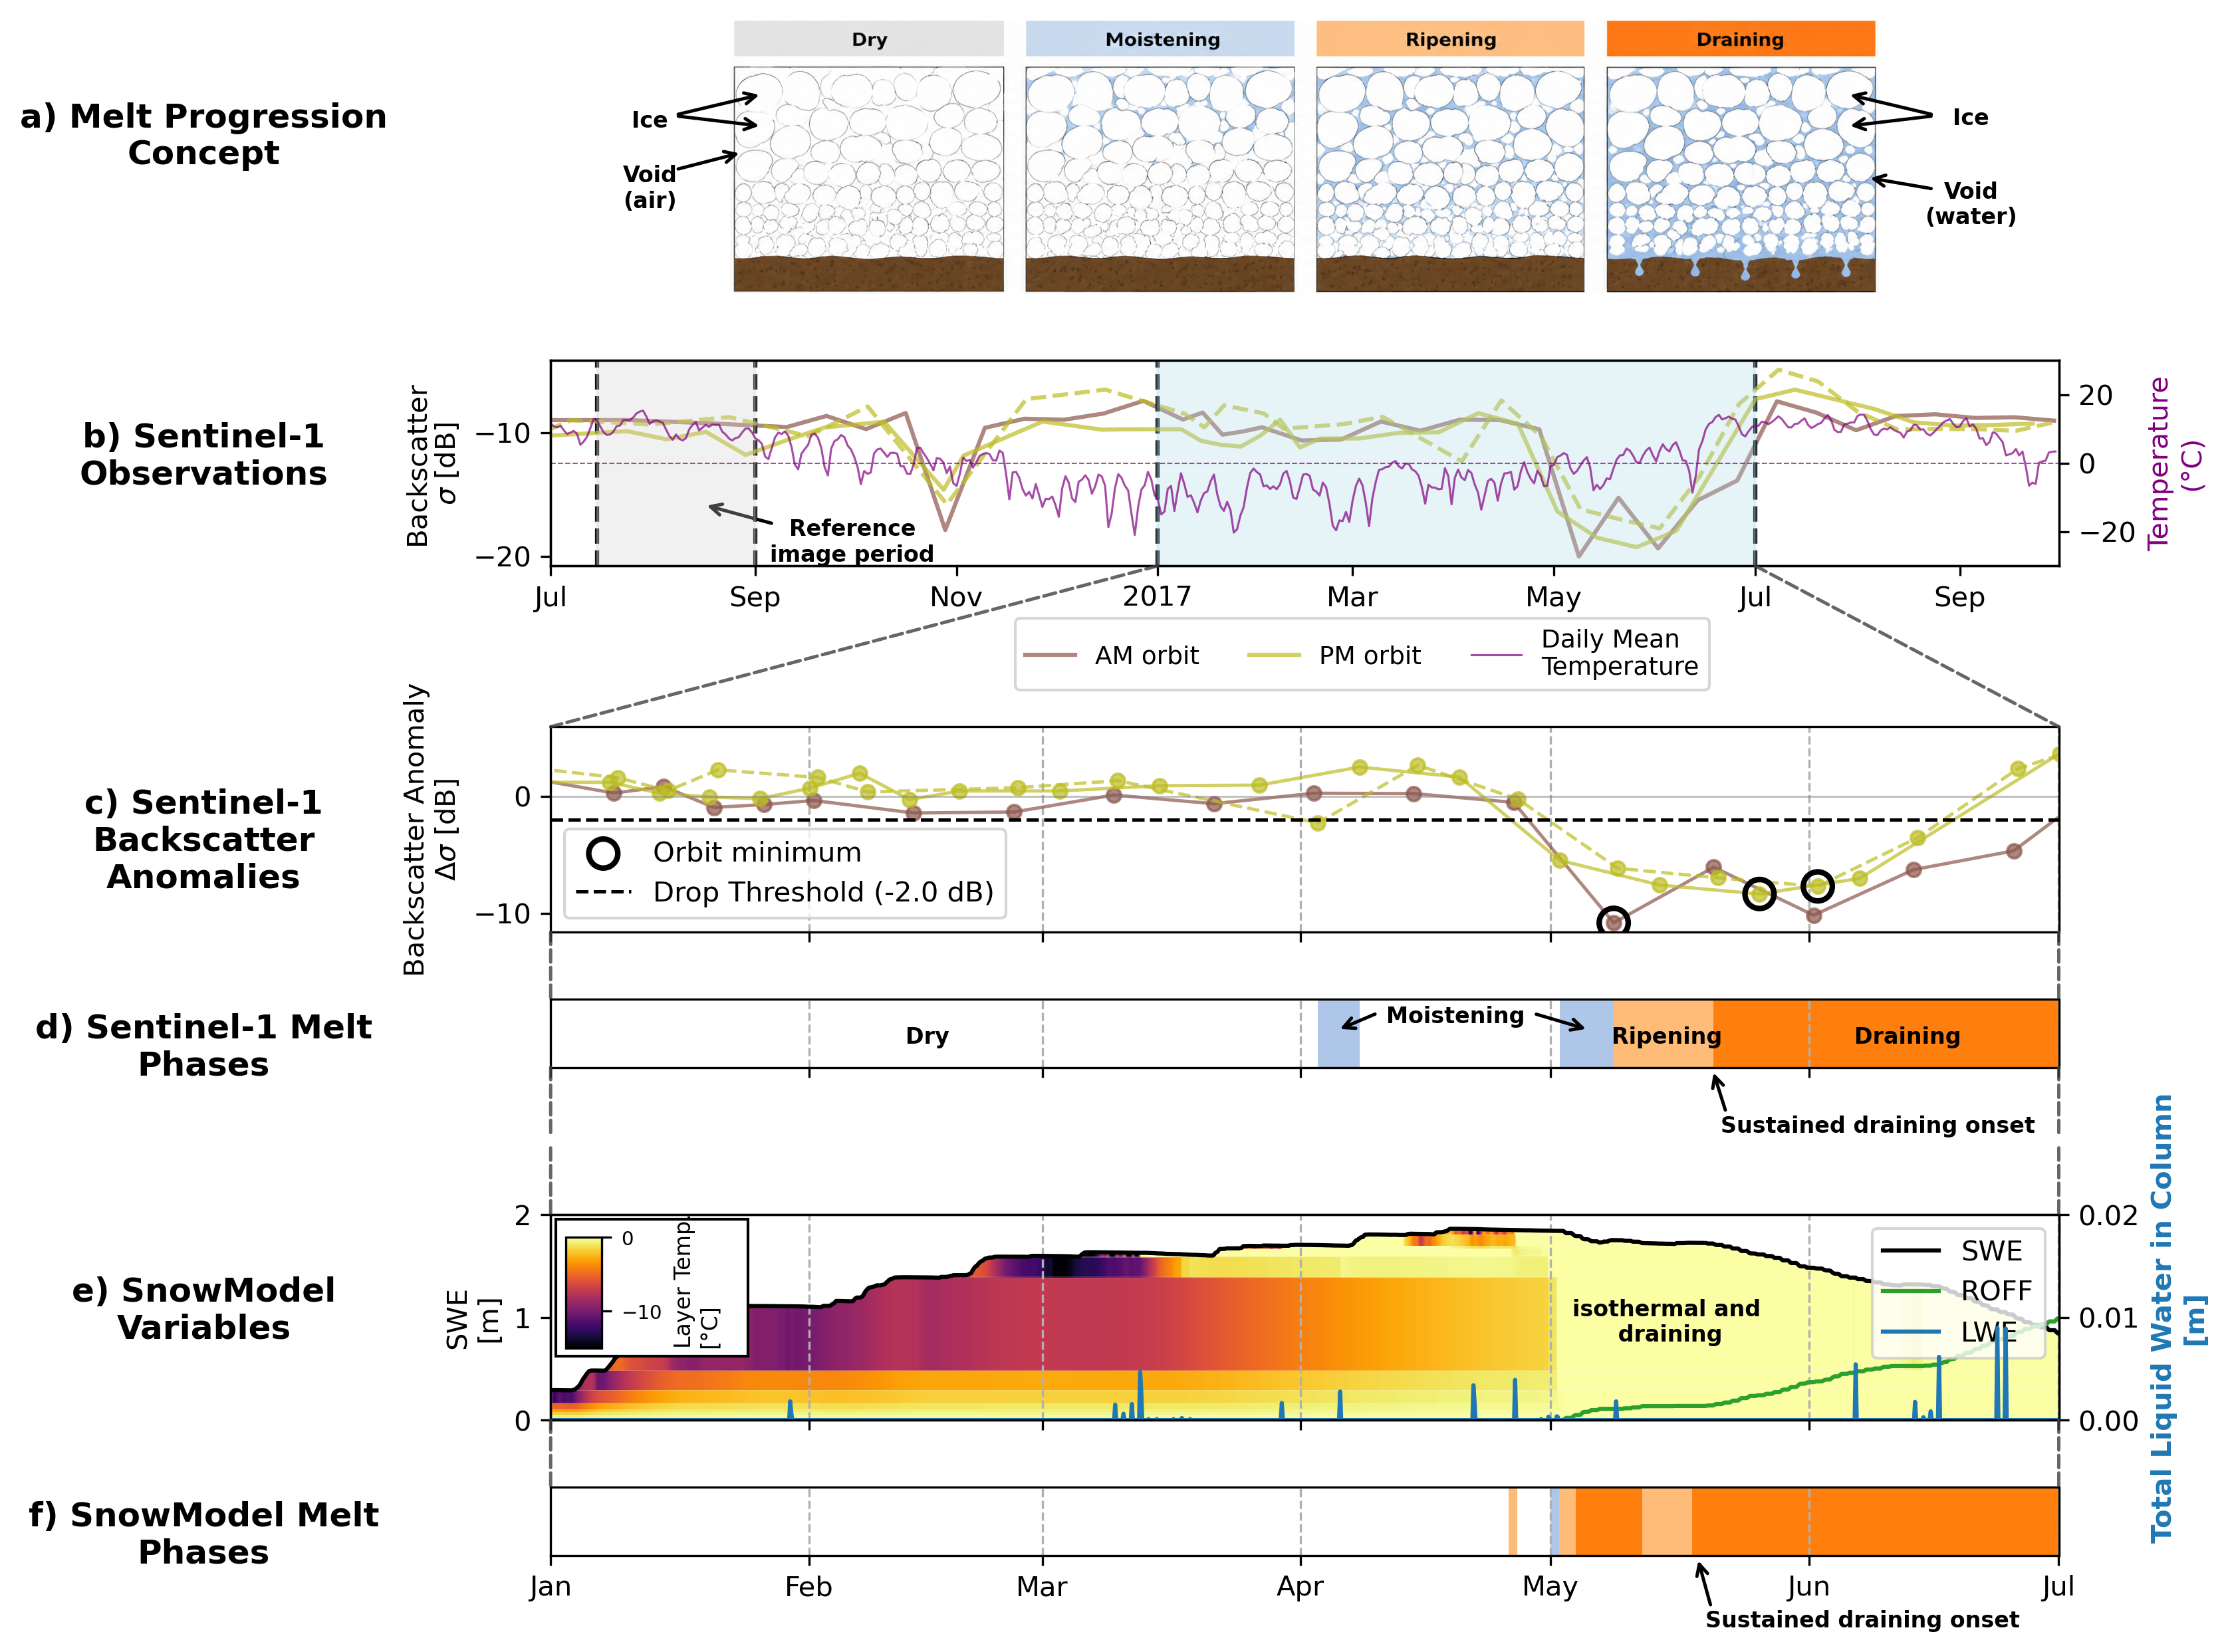

In [19]:
import copy
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle
import matplotlib.image as mpimg

s1_bsc_prev_yr1_ds_cp = copy.deepcopy(s1_bsc_prev_yr1_ds)
s1_bsc_yr1_ds_cp = copy.deepcopy(s1_bsc_yr1_ds)
s1_ref_yr1_ds_cp = copy.deepcopy(s1_ref_yr1_ds)
ds_s1_vv_yr1_cp = copy.deepcopy(ds_s1_vv_yr1)

s1_bsc_yr1_ds_cp['bscatter'] *= 1.12


ds_5yr = xr.concat([s1_bsc_prev_yr1_ds_cp,
                    s1_bsc_yr1_ds_cp,
                   ],dim = 'time')
ds_5yr = ds_5yr.where(ds_5yr.band == 'vv',drop = True)
ds_5yr = ds_5yr.where(ds_5yr.time < np.datetime64('2018-10-01'),drop = True) \
                .isel({'x':ix,'y':iy})
ds_137 = ds_5yr.where(ds_5yr['sat:relative_orbit'] == 137,drop = True)
ds_144 = ds_5yr.where(ds_5yr['sat:relative_orbit'] == 144,drop = True)
ds_64 = ds_5yr.where(ds_5yr['sat:relative_orbit'] == 64,drop = True)

fig = plt.figure(figsize=(12, 10), dpi=300)

gs = fig.add_gridspec(
    8, 2,
    width_ratios=[1.0, 5.0],   # left legend space, right plot space
    height_ratios=[2.0,1.5, 0.2,1.5, 0.5, 0.1,1.5, 0.5],
    hspace=0.5,
    wspace=0.05
)

# Top plot spans full width
ax_conc = fig.add_subplot(gs[0, 1])
ax0 = fig.add_subplot(gs[1, 1])
ax10 = fig.add_subplot(gs[2, 1],sharex=ax0)

# Left legend axes
legconc = fig.add_subplot(gs[0, 0])
leg0 = fig.add_subplot(gs[1, 0])
leg1 = fig.add_subplot(gs[3, 0])
leg3 = fig.add_subplot(gs[4, 0])
leg5 = fig.add_subplot(gs[5, 0])
leg7 = fig.add_subplot(gs[6, 0])
leg9 = fig.add_subplot(gs[7, 0])

for ax in [legconc,leg0,leg1, leg3, leg5, leg7,leg9]:
    ax.axis("off")

# Right-side plotting axes
ax1 = fig.add_subplot(gs[3, 1])

ax3 = fig.add_subplot(gs[4, 1], sharex=ax1)
ax5 = fig.add_subplot(gs[5, 1], sharex=ax1)
ax7 = fig.add_subplot(gs[6, 1], sharex=ax1)
ax9 = fig.add_subplot(gs[7, 1], sharex=ax1)

ax10.axis('off')


img = mpimg.imread("./pngs/snowmelt_conceptual.png")

# Auto-crop the whitespace margin around the four panels by finding the
# bounding box of non-white pixels, then let imshow preserve the image's
# true pixel aspect ratio (aspect="equal") instead of stretching it into
# a hand-tuned xlim/ylim box.
rgb = img[..., :3]
white_thresh = 0.98 if np.issubdtype(img.dtype, np.floating) else 250
content_mask = np.any(rgb < white_thresh, axis=-1)
content_rows = np.where(content_mask.any(axis=1))[0]
content_cols = np.where(content_mask.any(axis=0))[0]
img_cropped = img[
    content_rows.min():content_rows.max() + 1,
    content_cols.min():content_cols.max() + 1,
]

ax_conc.clear()
ax_conc.imshow(img_cropped, aspect="equal")
# arrows
ax_conc.annotate(
    "",
    xy=(0.03, 0.73),          # center of left blue box
    xytext=(-0.05, 0.65),      # beginning of text
    xycoords=ax_conc.transAxes,
    textcoords=ax_conc.transAxes,
    arrowprops=dict(
        arrowstyle="->",
        lw=1.2,
        color="black",
    ),
)
ax_conc.annotate(
    "",
    xy=(0.03, 0.61),          # center of left blue box
    xytext=(-0.05, 0.65),      # beginning of text
    xycoords=ax_conc.transAxes,
    textcoords=ax_conc.transAxes,
    arrowprops=dict(
        arrowstyle="->",
        lw=1.2,
        color="black",
    ),
)
ax_conc.text(
    -0.07, 0.67,
    "Ice",
    transform=ax_conc.transAxes,
    ha="center",
    va="top",
    fontsize=8,
    fontweight="bold",
)
ax_conc.annotate(
    "",
    xy=(0.0125, 0.5175),          # center of left blue box
    xytext=(-0.05, 0.45),      # beginning of text
    xycoords=ax_conc.transAxes,
    textcoords=ax_conc.transAxes,
    arrowprops=dict(
        arrowstyle="->",
        lw=1.2,
        color="black",
    ),
)
ax_conc.text(
    -0.07, 0.47,
    "Void\n(air)",
    transform=ax_conc.transAxes,
    ha="center",
    va="top",
    fontsize=8,
    fontweight="bold",
)

ax_conc.annotate(
    "",
    xy=(0.97, 0.73),          # center of left blue box
    xytext=(1.05, 0.65),      # beginning of text
    xycoords=ax_conc.transAxes,
    textcoords=ax_conc.transAxes,
    arrowprops=dict(
        arrowstyle="->",
        lw=1.2,
        color="black",
    ),
)
ax_conc.annotate(
    "",
    xy=(0.97, 0.61),          # center of left blue box
    xytext=(1.05, 0.65),      # beginning of text
    xycoords=ax_conc.transAxes,
    textcoords=ax_conc.transAxes,
    arrowprops=dict(
        arrowstyle="->",
        lw=1.2,
        color="black",
    ),
)
ax_conc.text(
    1.08, 0.68,
    "Ice",
    transform=ax_conc.transAxes,
    ha="center",
    va="top",
    fontsize=8,
    fontweight="bold",
)

ax_conc.annotate(
    "",
    xy=(0.9875, 0.425),          # center of left blue box
    xytext=(1.05, 0.38),      # beginning of text
    xycoords=ax_conc.transAxes,
    textcoords=ax_conc.transAxes,
    arrowprops=dict(
        arrowstyle="->",
        lw=1.2,
        color="black",
    ),
)
ax_conc.text(
    1.08, 0.41,
    "Void\n(water)",
    transform=ax_conc.transAxes,
    ha="center",
    va="top",
    fontsize=8,
    fontweight="bold",
)


ax_conc.axis("off")




# ax0
__,handles0,labels0 = subplot0(ds_144,ds_137,ds_64,ax0,sim_years = [2017],xmax_ = '2017-10-01')
ax0_ = ax0.twinx()
lt = wrf_temp_daily.T2.plot(ax=ax0_,color = 'purple',linewidth = 0.75,alpha = 0.7)
ax0_.axhline(0,linestyle = '--',linewidth = 0.5,color = 'purple',alpha = 0.7)
ax0_.set_ylim(-30,30)
ax0_.set_title('')
ax0_.set_ylabel("Temperature\n(°C)",color = 'purple')

ax0.text(
    0.20, 0.23,
    "Reference\nimage period",
    transform=ax0.transAxes,
    ha="center",
    va="top",
    fontsize=8,
    fontweight="bold",
)
ax0.annotate(
    "",
    xy=(0.1, 0.3),          # center of left blue box
    xytext=(0.15, 0.20),      # beginning of text
    xycoords=ax0.transAxes,
    textcoords=ax0.transAxes,
    arrowprops=dict(
        arrowstyle="->",
        lw=1.2,
        color="black",
    ),
)

leg0_ = ax0.legend(
    handles0[2:] + lt,
    labels0[2:] + ['Daily Mean\nTemperature'],
    loc="center left",
    # bbox_to_anchor=(-0.01, -0.45),
    bbox_to_anchor=(0.30, -0.43),
    ncol=3,
    frameon=True,
    fontsize=9,
)



__,result1 = backscatter_anomalies(ds_s1_vv_yr1_cp, 
                                s1_bsc_yr1_ds_cp, 
                                s1_ref_yr1_ds_cp, 
                                qcPass=True,
                                idx_=ix,#21
                                idy_=iy,#11
                                geog=lyell_gdf_proj,
                                xmin_ = '2017-01-01',
                                xmax_ = '2017-07-01',
                                showRef_Period = False,
                                dropOrbit64 = False,
                                ax=ax1,
                                title='',
                                pltLegend = False,
                                add_buff = 1.0,
                                )
ax1.tick_params(axis='x', labelbottom=False)
ax1.set_xlabel('')


# ax3
plot_phase_intervals(ax3, result1["phases"], label="S1-VV")
ax3.text(
    0.9, 0.6,
    "Draining",
    transform=ax3.transAxes,
    ha="center",
    va="top",
    fontsize=8,
    fontweight="bold",
)
ax3.text(
    0.74, 0.6,
    "Ripening",
    transform=ax3.transAxes,
    ha="center",
    va="top",
    fontsize=8,
    fontweight="bold",
)
ax3.text(
    0.6, 0.9,
    "Moistening",
    transform=ax3.transAxes,
    ha="center",
    va="top",
    fontsize=8,
    fontweight="bold",
)
ax3.text(
    0.25, 0.6,
    "Dry",
    transform=ax3.transAxes,
    ha="center",
    va="top",
    fontsize=8,
    fontweight="bold",
)
ax3.annotate(
    "",
    xy=(0.52, 0.53),          # center of left blue box
    xytext=(0.55, 0.81),      # beginning of text
    xycoords=ax3.transAxes,
    textcoords=ax3.transAxes,
    arrowprops=dict(
        arrowstyle="->",
        lw=1.2,
        color="black",
    ),
)
ax3.annotate(
    "",
    xy=(0.69, 0.54),          # center of right blue box
    xytext=(0.65, 0.80),      # end of text
    xycoords=ax3.transAxes,
    textcoords=ax3.transAxes,
    arrowprops=dict(
        arrowstyle="->",
        lw=1.2,
        color="black",
    ),
)

# sustained draining.
ax3.text(
    0.88, -0.7,
    "Sustained draining onset",
    transform=ax3.transAxes,
    ha="center",
    va="top",
    fontsize=8,
    fontweight="bold",
)

ax3.annotate(
    "",
    xy=(0.77, -0.0),          # center of right blue box
    xytext=(0.78, -0.7),      # end of text
    xycoords=ax3.transAxes,
    textcoords=ax3.transAxes,
    arrowprops=dict(
        arrowstyle="->",
        lw=1.2,
        color="black",
    ),
)

ax3.tick_params(axis='x', labelbottom=False)
ax5.axis('off')

plot_ml_sm(sm_point_ds_2017,ax7)
ax7.text(
    4.85, 3.75,
    "isothermal and\n draining",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=8,
    fontweight="bold",
)
ax7.tick_params(axis='x', labelbottom=False)

# Grab the most recent imshow gradient from ax5
gradient = ax7.images[-1]




cax = inset_axes(
    leg7,
    width="12%",
    height="45%",
    loc="lower left",
    bbox_to_anchor=(1.2, 0.35, 1, 1.2),
    bbox_transform=leg7.transAxes,
    borderpad=0,
)

cax.set_zorder(10)

cbar = fig.colorbar(gradient, cax=cax, orientation="vertical")
cbar.set_label("Layer Temp.\n[°C]", fontsize=8, loc="bottom")

# force matplotlib to compute label/tick positions
fig.canvas.draw()

# get full colorbar bbox including tick labels and label
bbox = cax.get_tightbbox(fig.canvas.get_renderer())
bbox_fig = bbox.transformed(fig.transFigure.inverted())

# optional padding around box
pad = 0.004
bg = Rectangle(
    (bbox_fig.x0 - pad, bbox_fig.y0 - pad),
    bbox_fig.width + 2 * pad,
    bbox_fig.height + 2 * pad,
    transform=fig.transFigure,
    facecolor="white",      # or "lightgray"
    edgecolor="black",
    zorder=9,
)

fig.patches.append(bg)

cbar.ax.tick_params(labelsize=7)

plot_sm_phases(
    ax9,
    ds_sm_yr1_lyell_matched
)
ax9.text(
    0.87, -0.8,
    "Sustained draining onset",
    transform=ax9.transAxes,
    ha="center",
    va="top",
    fontsize=8,
    fontweight="bold",
)

ax9.annotate(
    "",
    xy=(0.76, -0.0),          # center of right blue box
    xytext=(0.77, -0.8),      # end of text
    xycoords=ax9.transAxes,
    textcoords=ax9.transAxes,
    arrowprops=dict(
        arrowstyle="->",
        lw=1.2,
        color="black",
    ),
)
# ax9.set_title('F) SM Melt Phase Progression',fontweight = 'bold')


legconc.text(
    0.0, 0.7,
    "a) Melt Progression\nConcept",
    transform=legconc.transAxes,
    ha="center",
    va="top",
    fontsize=12,
    fontweight="bold",
)

leg0.text(
    0.0, 0.7,
    "b) Sentinel-1\nObservations",
    transform=leg0.transAxes,
    ha="center",
    va="top",
    fontsize=12,
    fontweight="bold",
)
leg1.text(
    0.0, 0.7,
    "c) Sentinel-1\nBackscatter\nAnomalies",
    transform=leg1.transAxes,
    ha="center",
    va="top",
    fontsize=12,
    fontweight="bold",
)
leg3.text(
    0.0, 0.8,
    "d) Sentinel-1 Melt\nPhases",
    transform=leg3.transAxes,
    ha="center",
    va="top",
    fontsize=12,
    fontweight="bold",
)
leg7.text(
    0.0, 0.7,
    "e) SnowModel\nVariables",
    transform=leg7.transAxes,
    ha="center",
    va="top",
    fontsize=12,
    fontweight="bold",
)
leg9.text(
    0.0, 0.8,
    "f) SnowModel Melt\nPhases",
    transform=leg9.transAxes,
    ha="center",
    va="top",
    fontsize=12,
    fontweight="bold",
)



# connect_axes_by_date(fig, ax0, ax1, "2017-01-01")
# connect_axes_by_date(fig, ax0, ax1, "2017-07-01")
for d in ["2017-01-01", "2017-07-01"]:
    connect_axes_by_date(fig, ax0, ax1, d)
    connect_axes_by_date(fig, ax1, ax3, d)
    connect_axes_by_date(fig, ax3, ax5, d)
    connect_axes_by_date(fig, ax5, ax7, d)
    connect_axes_by_date(fig, ax7, ax9, d)

plt.savefig('./pngs/F03_conceptual_methods.png',dpi = 300)